In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.layers import BatchNormalization
from keras.optimizers import Adam
import tensorflow as tf

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('preprocessed_data.csv', sep=',', quotechar='"', encoding='utf-8')
print(df.head(2).to_markdown(index = False))
print("原始数据形状:", df.shape)

|    T |     P |   U |   Ff |   Tn |   Tx |   VV |   Td |
|-----:|------:|----:|-----:|-----:|-----:|-----:|-----:|
| 25.2 | 751.5 |  79 |    1 | 23.6 | 33   |    6 | 21.3 |
| 27.7 | 753   |  70 |    1 | 23.6 | 35.3 |    4 | 21.7 |
原始数据形状: (29221, 8)


In [4]:
null_rows_count = df.isna().any(axis=1).sum()
print(f"包含空数据的行数: {null_rows_count}")

包含空数据的行数: 0


### Method1

In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_values, columns=df.columns)

In [6]:
print(scaled_df.shape)

(29221, 8)


In [7]:
def make_supervised_data(data, n_input=100, n_out=1, target_idx=2):
    n_vars = data.shape[1]
    cols = []
    
    for i in range(n_input, 0, -1):
        cols.append(data.shift(i))
    
    for i in range(0, n_out):
        cols.append(data.iloc[:, target_idx].shift(-i))
    
    agg = pd.concat(cols, axis=1)
    
    input_names = [f'{col}(t-{i})' 
                   for i in range(n_input, 0, -1) 
                   for col in data.columns]
    output_names = [f'U(t+{i})' if i > 0 else 'U(t)' for i in range(0, n_out)]
    agg.columns = input_names + output_names
    
    agg.dropna(inplace=True)
    return agg

In [8]:
n_input = 100  
n_out = 50     
target_idx = 2 

reframed = make_supervised_data(scaled_df, n_input, n_out, target_idx)
print(f"监督数据集形状: {reframed.shape}")

values = reframed.values
n_train = int(len(values) * 0.8)
train = values[:n_train, :]
test = values[n_train:, :]

X_train, y_train = train[:, :-n_out], train[:, -n_out:]
X_test, y_test = test[:, :-n_out], test[:, -n_out:]

print(f"X_train原始形状: {X_train.shape}, y_train原始形状: {y_train.shape}")
print(f"X_test原始形状: {X_test.shape}, y_test原始形状: {y_test.shape}")

n_features = df.shape[1]
X_train = X_train.reshape((X_train.shape[0], n_input, n_features))
X_test = X_test.reshape((X_test.shape[0], n_input, n_features))

print(f"X_train重塑后: {X_train.shape}, X_test重塑后: {X_test.shape}")

监督数据集形状: (29072, 850)
X_train原始形状: (23257, 800), y_train原始形状: (23257, 50)
X_test原始形状: (5815, 800), y_test原始形状: (5815, 50)
X_train重塑后: (23257, 100, 8), X_test重塑后: (5815, 100, 8)


In [13]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(n_input, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(n_out))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=50,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/200

466/466 [==============================] - 28s 55ms/step - loss: 0.0717 - val_loss: 0.0428
Epoch 2/200
466/466 [==============================] - 28s 60ms/step - loss: 0.0502 - val_loss: 0.0422
Epoch 3/200
466/466 [==============================] - 29s 63ms/step - loss: 0.0477 - val_loss: 0.0417
Epoch 4/200
466/466 [==============================] - 29s 63ms/step - loss: 0.0459 - val_loss: 0.0410
Epoch 5/200
466/466 [==============================] - 29s 62ms/step - loss: 0.0449 - val_loss: 0.0407
Epoch 6/200
466/466 [==============================] - 28s 60ms/step - loss: 0.0440 - val_loss: 0.0399
Epoch 7/200
466/466 [==============================] - 29s 62ms/step - loss: 0.0404 - val_loss: 0.0353
Epoch 8/200
466/466 [==============================] - 30s 65ms/step - loss: 0.0366 - val_loss: 0.0322
Epoch 9/200
466/466 [==============================] - 36s 77ms/step - loss: 0.0357 - val_loss: 0.0320
Epoch 10/200
466/466 [==============================] - 36s 78ms/step - 

In [16]:
model.save('humidity_forecast_model.h5')

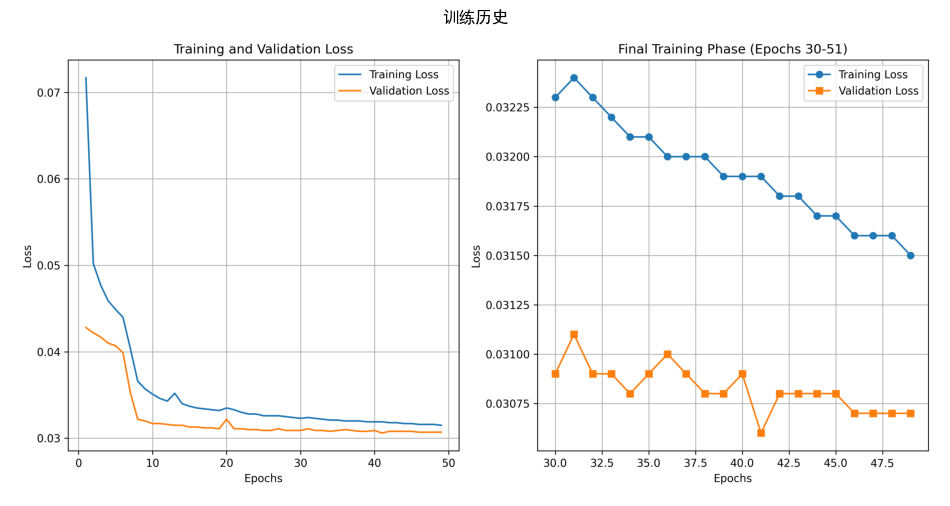

In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('lstm_training_history.png')

plt.figure(figsize=(12, 10))  
plt.imshow(img)
plt.axis('off')  
plt.title('训练历史')
plt.show()

In [9]:
from keras.models import load_model
model = load_model('humidity_forecast_model.h5')

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 64)           18688     
                                                                 
 dropout (Dropout)           (None, 100, 64)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 50)                3250      
                                                                 
Total params: 54962 (214.70 KB)
Trainable params: 54962 (214.70 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [16]:
def inverse_scale_predictions(y_values, scaler, target_idx, n_features):
    n_samples = y_values.shape[0]
    n_steps = y_values.shape[1]
    
    inverted_values = np.zeros((n_samples, n_steps))
    
    for step in range(n_steps):
        dummy = np.zeros((n_samples, n_features))
        dummy[:, target_idx] = y_values[:, step]
        inverted = scaler.inverse_transform(dummy)
        inverted_values[:, step] = inverted[:, target_idx]
        
    return inverted_values

In [15]:
y_pred = model.predict(X_test)

target_idx = 2  
n_features = df.shape[1]  

y_pred_inv = inverse_scale_predictions(y_pred, scaler, target_idx, n_features)

y_test_inv = inverse_scale_predictions(y_test, scaler, target_idx, n_features)

182/182 [==============================] - 3s 13ms/step


In [29]:
step_pred = y_pred_inv[:, 30]  
step_actual = y_test_inv[:, 30]
mse = mean_squared_error(step_actual, step_pred)
rmse = np.sqrt(mse)
r2 = r2_score(step_actual, step_pred)
mae = mean_absolute_error(step_actual, step_pred)

print("\n评估结果:")
print(f"均方误差(MSE): {mse:.4f}")
print(f"均方根误差(RMSE): {rmse:.4f}")
print(f"R平方(R2): {r2:.4f}")
print(f"平均绝对误差(MAE): {mae:.4f}")


评估结果:
均方误差(MSE): 265.7961
均方根误差(RMSE): 16.3033
R平方(R2): 0.2260
平均绝对误差(MAE): 13.1994


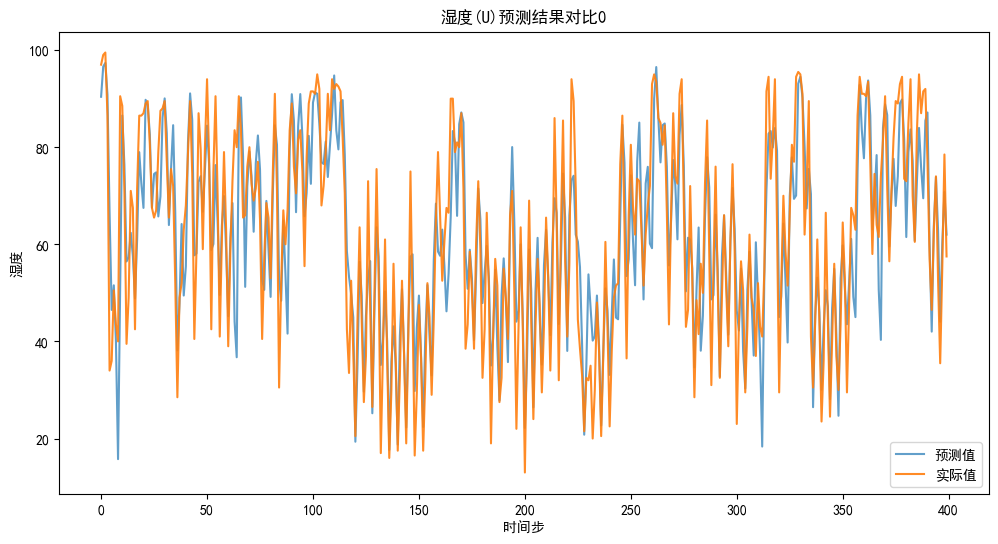

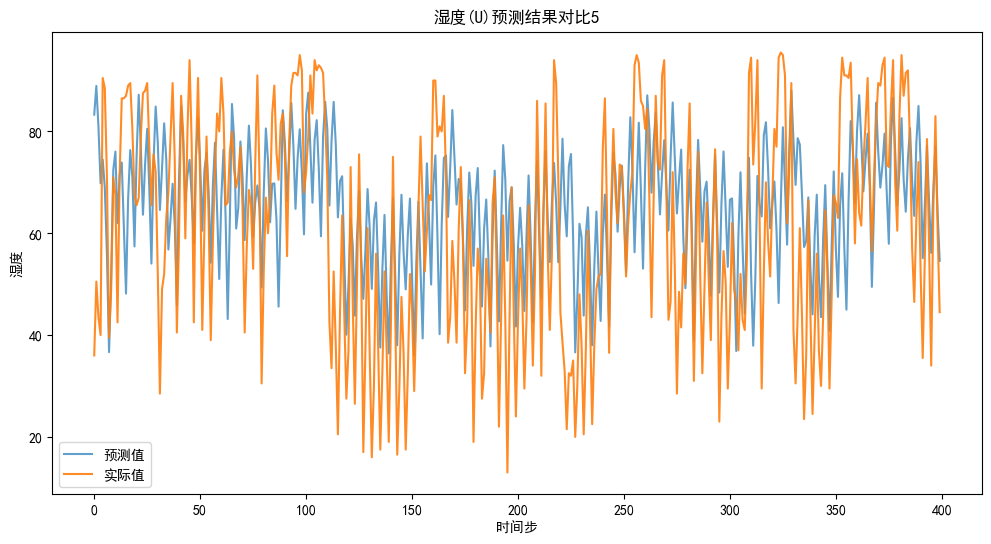

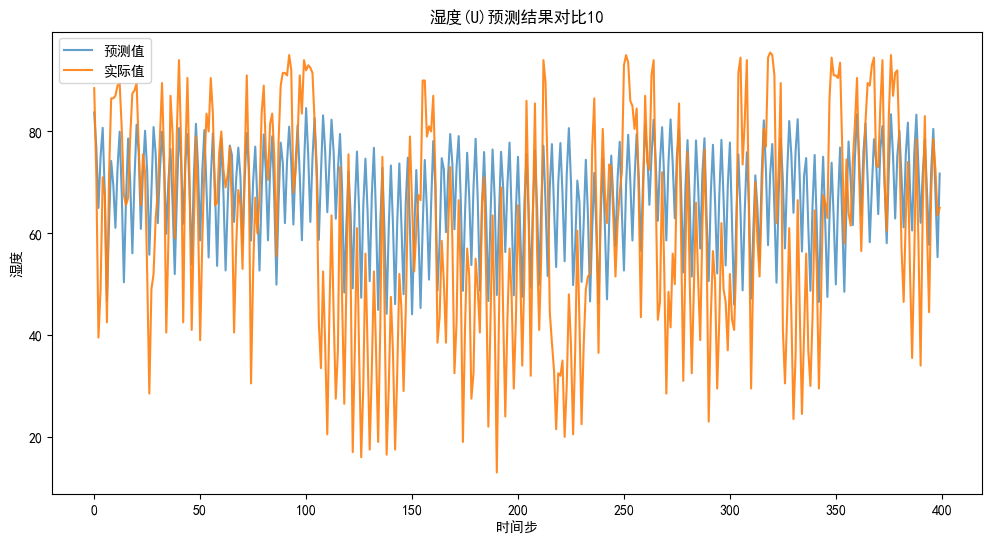

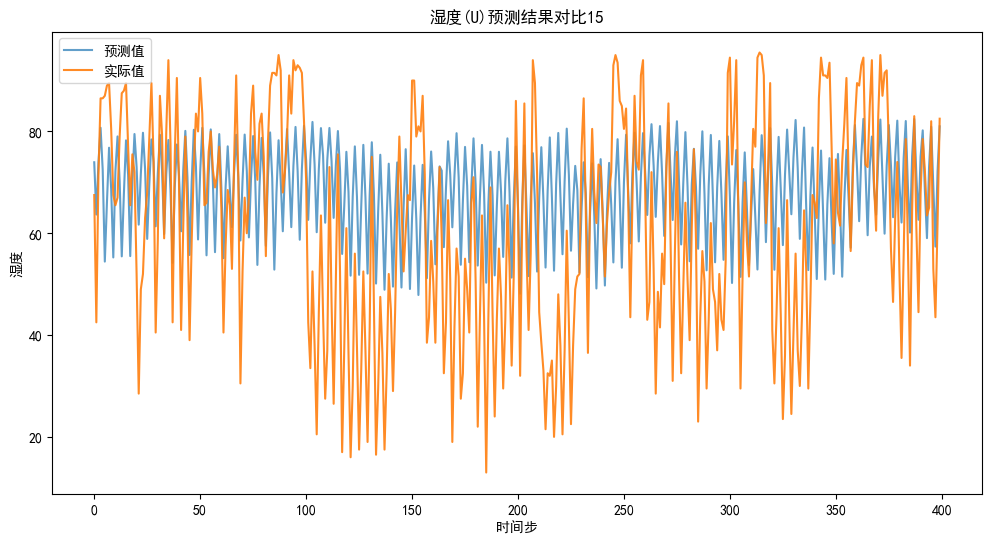

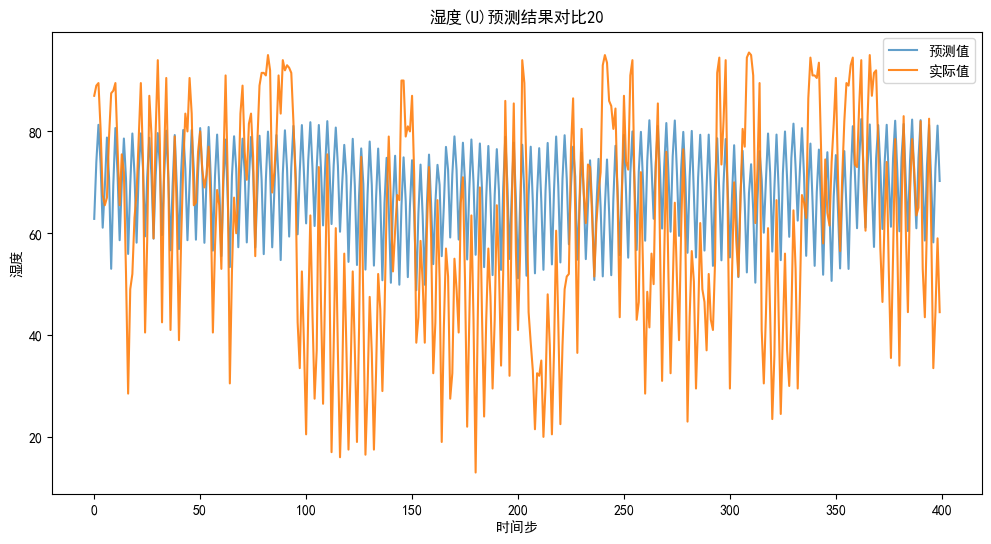

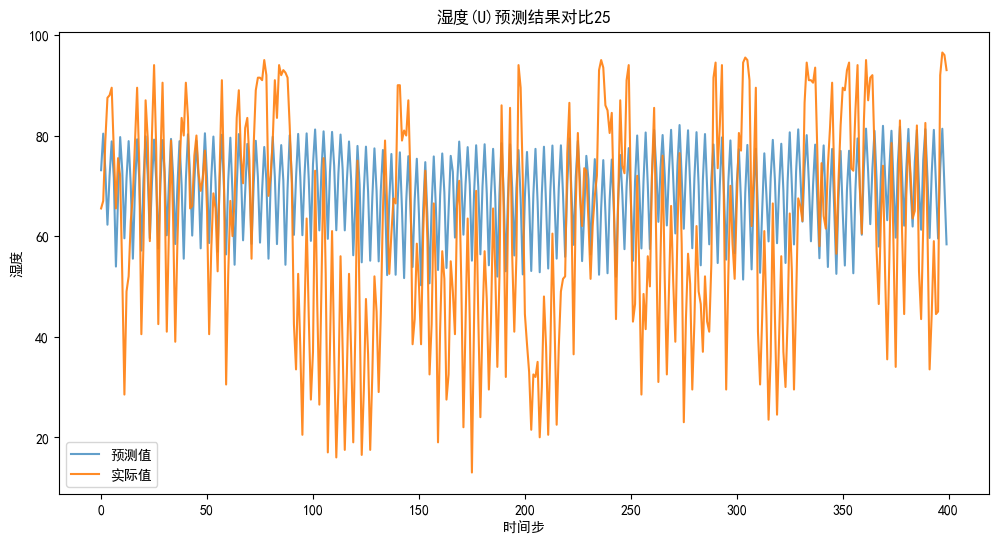

In [66]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

for i in range(0, 30, 5):
    plt.figure(figsize=(12, 6))
    plt.plot(y_pred_inv[-400:, i] , label='预测值', alpha=0.7)
    plt.plot(y_test_inv[-400:, i], label='实际值', alpha=0.9)
    plt.title(f'湿度(U)预测结果对比{i}')
    plt.ylabel('湿度')
    plt.xlabel('时间步')
    plt.legend()
    plt.show()

In [22]:
sample = scaled_df[-n_input:].values
sample = sample.reshape((1, n_input, sample.shape[1]))
print(sample.shape)
pred_res = model.predict(sample)
print(pred_res)
pred_res_inv = inverse_scale_predictions(pred_res, scaler, target_idx, n_features)
print(pred_res_inv[0][29])

(1, 100, 8)
1/1 [==============================] - 0s 21ms/step
[[0.71062773 0.57767737 0.72457474 0.8121489  0.69715434 0.5618381
  0.7154633  0.80650103 0.6931578  0.5588335  0.7120192  0.8033221
  0.68927926 0.55659187 0.7129955  0.8042979  0.69078624 0.558212
  0.71246606 0.80362153 0.68957376 0.55475736 0.7102984  0.80272335
  0.690055   0.5560774  0.7108639  0.80311745 0.6885234  0.554943
  0.711087   0.803175   0.68895257 0.55526644 0.71082634 0.8040551
  0.689532   0.55433244 0.7106379  0.8031387  0.6889626  0.5541
  0.71158206 0.8039864  0.6904985  0.55652565 0.71270883 0.80378145
  0.68913764 0.5541024 ]]
73.85337245464325


### 单次多步预测结果：73.85337245464325

### Method2

In [24]:
selected_features = ['T', 'P', 'U', 'Ff']
df_selected = df[selected_features]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(df_selected)
scaled_df = pd.DataFrame(scaled_values, columns=selected_features)

print("精简特征集形状:", scaled_df.shape)
print("特征顺序:", selected_features)

精简特征集形状: (29221, 4)
特征顺序: ['T', 'P', 'U', 'Ff']


In [25]:
# 3. 创建监督学习数据集
def create_supervised_dataset(data, n_input=100, n_output=1, target_col='U'):
    target_idx = data.columns.get_loc(target_col)
    n_vars = data.shape[1]
    X, y = [], []
    
    for i in range(len(data) - n_input - n_output + 1):
        inputs = data.iloc[i:i+n_input].values
        
        outputs = data.iloc[i+n_input:i+n_input+n_output, target_idx].values
        
        X.append(inputs)
        y.append(outputs)
    
    return np.array(X), np.array(y)

n_input = 100 
n_output = 50

X, y = create_supervised_dataset(scaled_df, n_input, n_output, target_col='U')
print(f"数据集形状 - X: {X.shape}, y: {y.shape}")

split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
print(f"训练集形状: {X_train.shape}, 测试集形状: {X_test.shape}")

数据集形状 - X: (29072, 100, 4), y: (29072, 50)
训练集形状: (23257, 100, 4), 测试集形状: (5815, 100, 4)


In [26]:
def build_model(n_input, n_features, n_output):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(n_input, n_features)),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(n_output)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

n_features = len(selected_features)
model = build_model(n_input, n_features, n_output)

In [51]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=50,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/200
466/466 [==============================] - 28s 54ms/step - loss: 0.0689 - val_loss: 0.0419
Epoch 2/200
466/466 [==============================] - 26s 55ms/step - loss: 0.0500 - val_loss: 0.0415
Epoch 3/200
466/466 [==============================] - 31s 66ms/step - loss: 0.0473 - val_loss: 0.0408
Epoch 4/200
466/466 [==============================] - 44s 95ms/step - loss: 0.0456 - val_loss: 0.0403
Epoch 5/200
466/466 [==============================] - 32s 68ms/step - loss: 0.0444 - val_loss: 0.0388
Epoch 6/200
466/466 [==============================] - 44s 94ms/step - loss: 0.0403 - val_loss: 0.0333
Epoch 7/200
466/466 [==============================] - 43s 91ms/step - loss: 0.0377 - val_loss: 0.0333
Epoch 8/200
466/466 [==============================] - 44s 94ms/step - loss: 0.0361 - val_loss: 0.0324
Epoch 9/200
466/466 [==============================] - 40s 85ms/step - loss: 0.0353 - val_loss: 0.0315
Epoch 10/200
466/466 [==============================] - 48s 102ms/step - 

In [56]:
import joblib

model.save('humidity_forecast_model3.h5')
joblib.dump(scaler, 'humidity_scaler.joblib')

metadata = {
    'selected_features': selected_features,
    'n_input': n_input,
    'n_output': n_output
}

import json
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f)

In [27]:
model = load_model('humidity_forecast_model3.h5')

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 100, 64)           17664     
                                                                 
 dropout_2 (Dropout)         (None, 100, 64)           0         
                                                                 
 lstm_3 (LSTM)               (None, 64)                33024     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 50)                3250      
                                                                 
Total params: 53938 (210.70 KB)
Trainable params: 53938 (210.70 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [28]:
# 8. 滚动迭代预测函数
def rolling_forecast(model, scaler, last_inputs, forecast_steps, external_forecast):
    features = scaler.get_feature_names_out()
    T_idx = list(features).index('T') if 'T' in features else -1
    P_idx = list(features).index('P') if 'P' in features else -1
    Ff_idx = list(features).index('Ff') if 'Ff' in features else -1
    U_idx = list(features).index('U') if 'U' in features else -1
    
    current_seq = last_inputs.reshape(1, n_input, n_features)
    predictions = []
    
    for step in range(forecast_steps):
        pred_norm = model.predict(current_seq)[0]
        
        if step < n_output:
            u_pred_norm = pred_norm[step]  
        else:
            u_pred_norm = pred_norm[-1]
            
        dummy = np.zeros((1, len(features)))
        dummy[0, U_idx] = u_pred_norm
        u_pred = scaler.inverse_transform(dummy)[0, U_idx]
        predictions.append(u_pred)
        
        T_forecast = external_forecast['T'][step] if 'T' in external_forecast else np.nan
        P_forecast = external_forecast['P'][step] if 'P' in external_forecast else np.nan
        Ff_forecast = external_forecast['Ff'][step] if 'Ff' in external_forecast else np.nan
        
        new_row = np.zeros(len(features))
        if T_idx >= 0: new_row[T_idx] = T_forecast
        if P_idx >= 0: new_row[P_idx] = P_forecast
        if U_idx >= 0: new_row[U_idx] = u_pred  
        if Ff_idx >= 0: new_row[Ff_idx] = Ff_forecast
        
        new_row_norm = scaler.transform(new_row.reshape(1, -1))[0]
        
        current_seq = np.roll(current_seq, -1, axis=1)
        current_seq[0, -1] = new_row_norm
    
    return predictions



In [30]:
last_inputs = scaled_df.iloc[-n_input:].values

import random
external_forecast = {
    'T': [22.8,28,24,20,25,33,24,23,26,34,27,22,26,35,29,27,27,32,27,25,24,27,24,24,24,26,24,22,24],
    'P': [755.7,751,752,753,754,754,754,754,755,753,753,752,752,750,750,749,749,748,749,749,751,751,751,750,749,746,747,748,750],
    'Ff': [2,1,2,1,2,1,3,2,1,3,5,2,3,3,3,3,2,1,2,1,3,2,2,3,4,5,4,3,2]
}

forecast_steps = 29
predicted_humidity = rolling_forecast(model, scaler, last_inputs, forecast_steps, external_forecast)

1/1 [==============================] - 0s 21ms/step


182/182 [==============================] - 3s 14ms/step
y_test_inv形状: (5815, 50)
y_pred_inv形状: (5815, 50)


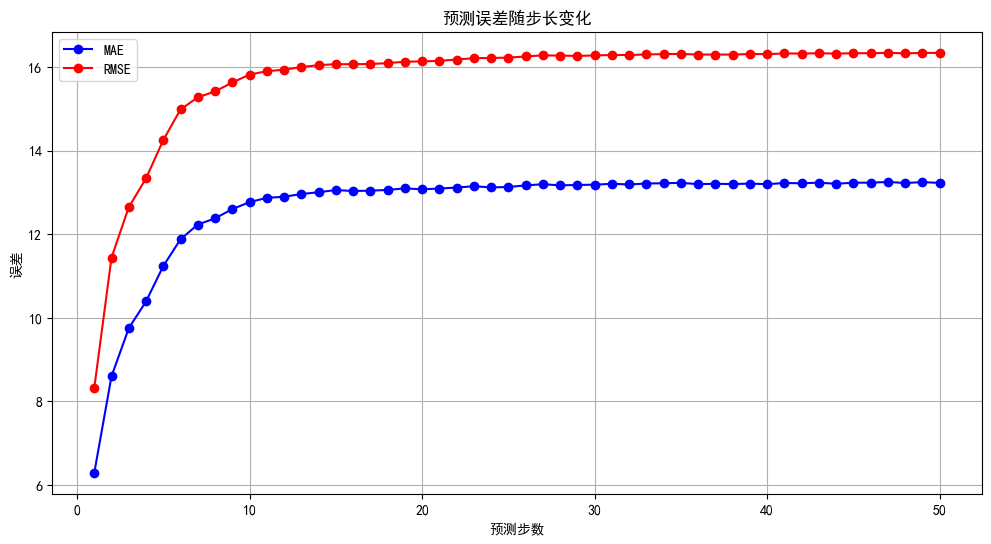


评估结果:
整体MAE: 12.6818
整体RMSE: 15.7234
第1步MAE: 6.2918
第50步MAE: 13.2271


In [62]:
def evaluate_forecast(model, scaler, X_test, y_test, selected_features):
    y_pred = model.predict(X_test)
    
    def inverse_target(values):
        n_samples, n_steps = values.shape
        flat_values = values.flatten()
        dummy = np.zeros((flat_values.size, len(selected_features)))
        dummy[:, selected_features.index('U')] = flat_values
        inverted = scaler.inverse_transform(dummy)
        return inverted[:, selected_features.index('U')].reshape(n_samples, n_steps)
    
    y_pred_inv = inverse_target(y_pred)
    
    y_test_inv = inverse_target(y_test)
    
    step_mae = []
    step_rmse = []
    
    print(f"y_test_inv形状: {y_test_inv.shape}")
    print(f"y_pred_inv形状: {y_pred_inv.shape}")
    
    for step in range(y_pred.shape[1]):
        step_actual = y_test_inv[:, step]
        step_pred = y_pred_inv[:, step]
        
        step_mae.append(mean_absolute_error(step_actual, step_pred))
        step_rmse.append(np.sqrt(mean_squared_error(step_actual, step_pred)))
    
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(step_mae)+1), step_mae, 'bo-', label='MAE')
    plt.plot(range(1, len(step_rmse)+1), step_rmse, 'ro-', label='RMSE')
    plt.title('预测误差随步长变化')
    plt.xlabel('预测步数')
    plt.ylabel('误差')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return {
        'step_mae': step_mae,
        'step_rmse': step_rmse,
        'overall_mae': np.mean(step_mae),
        'overall_rmse': np.mean(step_rmse)
    }

eval_results = evaluate_forecast(model, scaler, X_test, y_test, selected_features)

if eval_results:
    print("\n评估结果:")
    print(f"整体MAE: {eval_results['overall_mae']:.4f}")
    print(f"整体RMSE: {eval_results['overall_rmse']:.4f}")
    print(f"第1步MAE: {eval_results['step_mae'][0]:.4f}")
    print(f"第50步MAE: {eval_results['step_mae'][-1]:.4f}")

In [31]:
print("滚动迭代预测结果：", predicted_humidity[-1])

滚动迭代预测结果： 71.57125043869019


### 滚动迭代预测结果： 71.57125043869019